# Sequence Encoding & Genomic Intervals

A comprehensive walkthrough of the `seq_tools` and `training` modules in **sequence-foundation-model-tools**.

This notebook exercises every major module with synthetic data — no genome files or GPU required. It serves as both a quickstart guide and a smoke test.

**Modules covered:**
1. Sequence encoding (one-hot, reverse complement, chromosome normalization)
2. Genomic interval generation, centering, and output bin mapping
3. Splicing label generation from synthetic rMATS/StringTie data
4. SNV variant construction
5. Custom loss functions (PSI, Bhattacharyya, masked MSE/Poisson)
6. Multitask head architectures (Split, Conditional, Calibrated)
7. LoRA injection, parameter counting, and weight merging
8. Windowed genomic dataset from sharded `.npz` files
9. Edge cases and input validation

## 1. Import All Modules and Verify Installation

In [1]:
import sys, importlib
import numpy as np
import pandas as pd
import torch

print(f"Python  {sys.version}")
print(f"NumPy   {np.__version__}")
print(f"Pandas  {pd.__version__}")
print(f"PyTorch {torch.__version__}")

# Core modules (should always succeed after pip install -e .)
from seq_tools.encoding import one_hot_encode, decode_one_hot, reverse_complement, normalize_chrom
from seq_tools.intervals import generate_intervals, make_input_interval, genome_to_output_bins
from seq_tools.variant import generate_snvs, generate_window_variants, variants_to_dataframe
from training.losses import PSILoss, BhattacharyyaLoss, MaskedMSELoss, MaskedPoissonLoss
from training.multitask_head import NonlinearHead, SplitHead, ConditionalHead, CalibratedHeadWrapper
from training.finetune import LoRAConfig, inject_lora, merge_lora, count_trainable_params
from training.dataset import GenomicWindowDataset, rasterize_window

print("\n✓ All core modules imported successfully")

# Optional dependencies
for pkg in ["grelu", "pysam", "pyranges"]:
    if importlib.util.find_spec(pkg):
        print(f"  {pkg:<12s} available")
    else:
        print(f"  {pkg:<12s} not installed (optional)")

Python  3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:42:22) [GCC 14.3.0]
NumPy   1.26.4
Pandas  2.3.3
PyTorch 2.4.0+cu121

✓ All core modules imported successfully
  grelu        available
  pysam        available
  pyranges     available


## 2. Sequence Encoding: One-Hot and Reverse Complement

The encoding module maps DNA strings to `(L, 4)` float32 arrays with channel order **ACGT**. Ambiguous bases (`N`) are encoded as all-zero rows.

In [2]:
# Basic encoding
seq = "ACGTACGT"
encoded = one_hot_encode(seq)
print(f"Input:  {seq}")
print(f"Shape:  {encoded.shape}  dtype: {encoded.dtype}")
print(f"First 4 positions (identity matrix for ACGT):\n{encoded[:4]}")

assert encoded.shape == (len(seq), 4)
assert encoded.dtype == np.float32

# Round-trip
decoded = decode_one_hot(encoded)
assert decoded == seq
print(f"\nDecoded: {decoded} (round-trip ✓)")

# Case-insensitive
assert np.array_equal(one_hot_encode("acgt"), one_hot_encode("ACGT"))
print("Case-insensitive ✓")

# Ambiguous bases
n_enc = one_hot_encode("N")
assert n_enc.sum() == 0.0
print("Ambiguous base (N) → all-zero ✓")

# Mixed with N
mixed = one_hot_encode("ANGC")
assert mixed[1].sum() == 0.0  # N position is zero
print("Mixed sequence with N ✓")

Input:  ACGTACGT
Shape:  (8, 4)  dtype: float32
First 4 positions (identity matrix for ACGT):
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Decoded: ACGTACGT (round-trip ✓)
Case-insensitive ✓
Ambiguous base (N) → all-zero ✓
Mixed sequence with N ✓


In [3]:
# Reverse complement
print("Reverse complement examples:")
for s in ["AAAA", "ATCG", "ACGT"]:
    rc = reverse_complement(s)
    print(f"  {s} → {rc}")

assert reverse_complement("AAAA") == "TTTT"
assert reverse_complement("ATCG") == "CGAT"
assert reverse_complement("ACGT") == "ACGT"  # palindrome
print("All reverse complement checks ✓")

Reverse complement examples:
  AAAA → TTTT
  ATCG → CGAT
  ACGT → ACGT
All reverse complement checks ✓


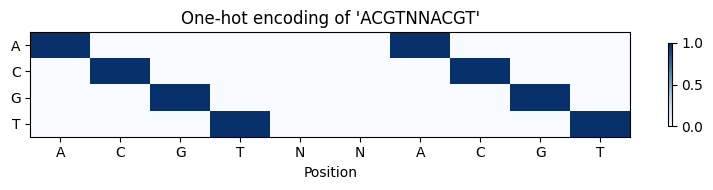

In [4]:
# Visualize a one-hot encoded sequence as a heatmap
import matplotlib.pyplot as plt

seq_vis = "ACGTNNACGT"
enc_vis = one_hot_encode(seq_vis)

fig, ax = plt.subplots(figsize=(8, 2))
im = ax.imshow(enc_vis.T, aspect="auto", cmap="Blues", interpolation="nearest")
ax.set_yticks(range(4))
ax.set_yticklabels(["A", "C", "G", "T"])
ax.set_xticks(range(len(seq_vis)))
ax.set_xticklabels(list(seq_vis))
ax.set_xlabel("Position")
ax.set_title(f"One-hot encoding of '{seq_vis}'")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [5]:
# Chromosome labeling normalization across assemblies
print("Chromosome normalization:")
print(f"  hg38:   '1'    → '{normalize_chrom('1', 'hg38')}'")
print(f"  hg38:   'chr1' → '{normalize_chrom('chr1', 'hg38')}'")
print(f"  GRCm39: 'chr1' → '{normalize_chrom('chr1', 'GRCm39')}'")
print(f"  GRCm39: '1'    → '{normalize_chrom('1', 'GRCm39')}'")
print(f"  mm10:   'chr1' → '{normalize_chrom('chr1', 'mm10')}'")

assert normalize_chrom("1", "hg38") == "chr1"
assert normalize_chrom("chr1", "GRCm39") == "1"
print("Normalization checks ✓")

Chromosome normalization:
  hg38:   '1'    → 'chr1'
  hg38:   'chr1' → 'chr1'
  GRCm39: 'chr1' → '1'
  GRCm39: '1'    → '1'
  mm10:   'chr1' → 'chr1'
Normalization checks ✓


## 3. Genomic Interval Generation and Bin Mapping

The intervals module tiles chromosomes into fixed-length windows for model input. For Borzoi-class models, the input is typically **524,288 bp** with the central **196,608 bp** producing output predictions at **32 bp** resolution.

In [6]:
# Build a synthetic chromosome table
chroms = pd.DataFrame({
    "chrom": ["chr1", "chr2", "chr3"],
    "length": [5_000_000, 3_000_000, 2_000_000],
})
print("Chromosome lengths:")
print(chroms.to_string(index=False))

# Tile with Borzoi-style parameters
seq_len = 524_288
stride = 174_762  # ~1/3 overlap
intervals = generate_intervals(chroms, seq_len=seq_len, stride=stride)

print(f"\nGenerated {len(intervals):,} intervals (seq_len={seq_len:,}, stride={stride:,})")
print(f"Columns: {list(intervals.columns)}")
print(intervals.head(10))

# Verify all intervals have the correct length
assert all(intervals["end"] - intervals["start"] == seq_len)
print(f"\n✓ All intervals are exactly {seq_len:,} bp")

Chromosome lengths:
chrom  length
 chr1 5000000
 chr2 3000000
 chr3 2000000

Generated 50 intervals (seq_len=524,288, stride=174,762)
Columns: ['chrom', 'start', 'end']
  chrom    start      end
0  chr1        0   524288
1  chr1   174762   699050
2  chr1   349524   873812
3  chr1   524286  1048574
4  chr1   699048  1223336
5  chr1   873810  1398098
6  chr1  1048572  1572860
7  chr1  1223334  1747622
8  chr1  1398096  1922384
9  chr1  1572858  2097146

✓ All intervals are exactly 524,288 bp


In [7]:
# Center a model input window on a region of interest (example: Borzoi input length)
# For example: an exon at chr1:1,000,000-1,001,000
input_iv = make_input_interval("chr1", 1_000_000, 1_001_000, seq_len=524_288)
print("Input interval centered on chr1:1,000,000-1,001,000:")
print(input_iv.to_string(index=False))

center = (input_iv["start"].iloc[0] + input_iv["end"].iloc[0]) / 2
print(f"Center: {center:,.0f} (midpoint of exon: {(1_000_000 + 1_001_000) / 2:,.0f}) ✓")

Input interval centered on chr1:1,000,000-1,001,000:
chrom  start     end strand
 chr1 738356 1262644      +
Center: 1,000,500 (midpoint of exon: 1,000,500) ✓


In [8]:
# Convert genome coordinates to model output bin indices
# Borzoi outputs 6144 bins (196,608 bp / 32 bp per bin) for the central window
input_start = input_iv["start"].iloc[0]
input_end = input_iv["end"].iloc[0]

bins = genome_to_output_bins(
    input_start=input_start,
    input_end=input_end,
    eval_start=1_000_000,
    eval_end=1_001_000,
    bin_size=32,
    output_window=196_608,
)

print(f"Exon chr1:1,000,000-1,001,000 maps to {len(bins)} output bins")
print(f"Bin range: [{bins[0]}, {bins[-1]}]")
print(f"Total output bins: {196_608 // 32} (196,608 bp / 32 bp)")

# These bins can be used to slice model output for element-level predictions
assert all(0 <= b < 196_608 // 32 for b in bins)
print("✓ All bins within valid range")

Exon chr1:1,000,000-1,001,000 maps to 32 output bins
Bin range: [3056, 3087]
Total output bins: 6144 (196,608 bp / 32 bp)
✓ All bins within valid range


## 4. SNV Variant Construction

The variant module generates all possible single-nucleotide variants at specified positions, producing 3 alternate alleles per position (excluding the reference base). This is the foundation for both targeted and saturating mutagenesis.

In [9]:
# Generate all SNVs for a short sequence
ref_seq = "ACGTACGT"
variants = generate_snvs(ref_seq)

print(f"Reference: {ref_seq}")
print(f"Total variants: {len(variants)} (expected: {len(ref_seq)} positions × 3 alts = {len(ref_seq) * 3})")
assert len(variants) == len(ref_seq) * 3

# Show as a DataFrame
df = variants_to_dataframe(variants)
print(f"\nVariant table (first 9 = all variants at positions 0-2):")
print(df.head(9).to_string(index=False))

# Targeted mutagenesis: only specific positions
targeted = generate_snvs(ref_seq, positions=[3, 4])
print(f"\nTargeted variants at positions 3-4: {len(targeted)} variants")
assert len(targeted) == 2 * 3

Reference: ACGTACGT
Total variants: 24 (expected: 8 positions × 3 alts = 24)

Variant table (first 9 = all variants at positions 0-2):
 position ref alt
        0   A   C
        0   A   G
        0   A   T
        1   C   A
        1   C   G
        1   C   T
        2   G   A
        2   G   C
        2   G   T

Targeted variants at positions 3-4: 6 variants


In [10]:
# Saturating mutagenesis within a window
long_seq = "ACGT" * 100  # 400 bp
window_variants = generate_window_variants(long_seq, start=50, end=60)
print(f"Saturating mutagenesis in window [50, 60):")
print(f"  Sequence length: {len(long_seq)}")
print(f"  Window: 10 bp → {len(window_variants)} variants")

# Each variant has the full mutated sequence
v = window_variants[0]
print(f"\n  Example variant: pos={v['position']}, ref={v['ref']}, alt={v['alt']}")
print(f"  Mutant differs at position {v['position']}: "
      f"'{long_seq[v['position']]}' → '{v['sequence'][v['position']]}'")
assert v["sequence"][v["position"]] == v["alt"]
print("  ✓ Variant construction correct")

Saturating mutagenesis in window [50, 60):
  Sequence length: 400
  Window: 10 bp → 30 variants

  Example variant: pos=50, ref=G, alt=A
  Mutant differs at position 50: 'G' → 'A'
  ✓ Variant construction correct


## 5. Custom Loss Functions

The training module provides loss functions designed for genomic prediction tasks:
- **PSILoss**: BCE with midpoint weighting — penalizes errors near PSI ≈ 0.5 more heavily
- **BhattacharyyaLoss**: Distribution overlap — good when signal shape matters more than pointwise accuracy
- **MaskedMSELoss** / **MaskedPoissonLoss**: Standard losses with per-bin masking for partially labeled data

In [11]:
# Create synthetic prediction and target tensors
B, T, L = 4, 3, 100  # batch, tasks, positions
pred = torch.sigmoid(torch.randn(B, T, L, requires_grad=True))
target = torch.rand(B, T, L)
mask = (torch.rand(B, T, L) > 0.3).float()  # ~70% coverage

print("Tensor shapes: pred/target/mask =", pred.shape)
print(f"Mask coverage: {mask.mean():.1%}")

# PSI Loss — higher weight near PSI=0.5
psi_loss = PSILoss(lambda_mid=25.0)
loss_psi = psi_loss(pred, target, mask)
loss_psi.backward(retain_graph=True)
print(f"\nPSILoss:             {loss_psi.item():.4f}  (gradient flows ✓)")

# Bhattacharyya Loss — distribution shape comparison
bhatt_loss = BhattacharyyaLoss()
loss_bhatt = bhatt_loss(pred.detach().requires_grad_(True), target, mask)
loss_bhatt.backward(retain_graph=True)
print(f"BhattacharyyaLoss:   {loss_bhatt.item():.4f}  (gradient flows ✓)")

# Masked MSE
mse_loss = MaskedMSELoss()
loss_mse = mse_loss(pred.detach().requires_grad_(True), target, mask)
loss_mse.backward(retain_graph=True)
print(f"MaskedMSELoss:       {loss_mse.item():.4f}  (gradient flows ✓)")

# Masked Poisson (targets should be non-negative counts)
poisson_loss = MaskedPoissonLoss()
count_target = torch.poisson(torch.ones(B, T, L) * 5)
count_pred = torch.abs(torch.randn(B, T, L, requires_grad=True)) + 0.1
loss_poisson = poisson_loss(count_pred, count_target, mask)
loss_poisson.backward()
print(f"MaskedPoissonLoss:   {loss_poisson.item():.4f}  (gradient flows ✓)")

Tensor shapes: pred/target/mask = torch.Size([4, 3, 100])
Mask coverage: 72.3%

PSILoss:             15.8539  (gradient flows ✓)
BhattacharyyaLoss:   0.0545  (gradient flows ✓)
MaskedMSELoss:       0.1330  (gradient flows ✓)
MaskedPoissonLoss:   2.7953  (gradient flows ✓)


In [12]:
# Demonstrate mask effect: loss changes when mask excludes high-error regions
pred_fixed = torch.tensor([[[0.9, 0.1, 0.5]]])   # B=1, T=1, L=3
tgt_fixed = torch.tensor([[[0.1, 0.9, 0.5]]])     # large errors at pos 0,1
mask_all = torch.ones(1, 1, 3)
mask_mid = torch.tensor([[[0.0, 0.0, 1.0]]])      # only keep the accurate position

loss_all = mse_loss(pred_fixed, tgt_fixed, mask_all)
loss_mid = mse_loss(pred_fixed, tgt_fixed, mask_mid)

print(f"MSE (all positions): {loss_all.item():.4f}")
print(f"MSE (only pos 2):    {loss_mid.item():.4f}")
print(f"Masking high-error positions reduces loss: {loss_mid.item() < loss_all.item()} ✓")

MSE (all positions): 0.4267
MSE (only pos 2):    0.0000
Masking high-error positions reduces loss: True ✓


## 6. Multitask Head Architectures

These prediction heads sit on top of a model trunk (e.g. Borzoi's 1920-channel features) and produce task-specific outputs:

| Head | Use case |
|------|----------|
| **NonlinearHead** | Simple multi-task projection |
| **SplitHead** | Per-task BatchNorm prevents output collapse across tasks |
| **ConditionalHead** | Cell-type-specific predictions from a single model |
| **CalibratedHeadWrapper** | Per-task affine calibration for fine-tuning |

In [13]:
# Use small dimensions for demonstration (real Borzoi uses in_channels=1920)
in_ch, hidden, task_hidden, n_tasks = 64, 32, 16, 3
B, L = 2, 50  # batch size, sequence length (bins)

trunk_features = torch.randn(B, in_ch, L)

# NonlinearHead
nl_head = NonlinearHead(in_channels=in_ch, hidden=hidden, out_channels=n_tasks)
out_nl = nl_head(trunk_features)
print(f"NonlinearHead:    input {trunk_features.shape} → output {out_nl.shape}")
assert out_nl.shape == (B, n_tasks, L)

# SplitHead (per-task normalization)
split_head = SplitHead(in_channels=in_ch, hidden=hidden, task_hidden=task_hidden, out_channels=n_tasks)
out_split = split_head(trunk_features)
print(f"SplitHead:        input {trunk_features.shape} → output {out_split.shape}")
assert out_split.shape == (B, n_tasks, L)

# ConditionalHead (cell-type conditioned)
n_celltypes = 5
cond_head = ConditionalHead(in_channels=in_ch, hidden=hidden, n_celltypes=n_celltypes, out_channels=1)
cell_ids = torch.tensor([2, 4])  # two different cell types in the batch
out_cond = cond_head(trunk_features, cell_type_id=cell_ids)
print(f"ConditionalHead:  input {trunk_features.shape} + cell_ids → output {out_cond.shape}")
assert out_cond.shape == (B, 1, L)

# Show that different cell types produce different outputs
out_ct0 = cond_head(trunk_features[:1], cell_type_id=torch.tensor([0]))
out_ct3 = cond_head(trunk_features[:1], cell_type_id=torch.tensor([3]))
print(f"\nDifferent cell types → different predictions: {not torch.allclose(out_ct0, out_ct3)} ✓")

NonlinearHead:    input torch.Size([2, 64, 50]) → output torch.Size([2, 3, 50])
SplitHead:        input torch.Size([2, 64, 50]) → output torch.Size([2, 3, 50])
ConditionalHead:  input torch.Size([2, 64, 50]) + cell_ids → output torch.Size([2, 1, 50])

Different cell types → different predictions: True ✓


In [14]:
# CalibratedHeadWrapper: adds per-task scale and bias on top of any head
cal_head = CalibratedHeadWrapper(base_head=nl_head, n_tasks=n_tasks)
out_cal = cal_head(trunk_features)
print(f"CalibratedHeadWrapper: output {out_cal.shape}")

# Parameter counts
for name, head in [("NonlinearHead", nl_head), ("SplitHead", split_head),
                   ("ConditionalHead", cond_head), ("CalibratedHead", cal_head)]:
    n_params = sum(p.numel() for p in head.parameters())
    print(f"  {name:25s} {n_params:>8,} parameters")

CalibratedHeadWrapper: output torch.Size([2, 3, 50])
  NonlinearHead                3,235 parameters
  SplitHead                    4,867 parameters
  ConditionalHead              4,353 parameters
  CalibratedHead               3,241 parameters


## 7. LoRA Injection, Parameter Counting, and Weight Merging

LoRA (Low-Rank Adaptation) adds small trainable adapters to frozen base layers. This implementation supports both `nn.Linear` and `nn.Conv1d`, matching the mixed architecture of Borzoi.

Key workflow:
1. **Inject** — wrap target layers with LoRA adapters, freeze everything else
2. **Train** — only adapter parameters (A, B matrices) are updated
3. **Merge** — fold adapter weights into base layers for zero-overhead inference

In [15]:
import logging
logging.basicConfig(level=logging.INFO, format="%(message)s")

# Build a toy model that mimics Borzoi's mixed Conv1d/Linear architecture
class ToyTrunk(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = torch.nn.Conv1d(4, 32, kernel_size=3, padding=1)
        self.relu = torch.nn.ReLU()
        self.conv2 = torch.nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn = torch.nn.BatchNorm1d(64)
        self.linear = torch.nn.Linear(64, 16)
        # Depthwise conv (should be skipped by LoRA)
        self.dw_conv = torch.nn.Conv1d(16, 16, kernel_size=3, padding=1, groups=16)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.bn(self.conv2(x))
        x = x.mean(dim=-1)  # global average pool
        x = self.linear(x)
        x = x.unsqueeze(-1).expand(-1, -1, 10)
        x = self.dw_conv(x)
        return x

model = ToyTrunk()
params_before = count_trainable_params(model)
print(f"Before LoRA: {params_before}")

# Inject LoRA into conv1, conv2, and linear (not depthwise)
cfg = LoRAConfig(
    rank=4,
    alpha=8,
    target_patterns=("conv1", "conv2", "linear"),
    freeze_norms=True,
    verbose=True,
)
inject_lora(model, cfg)

params_after = count_trainable_params(model)
print(f"\nAfter LoRA: {params_after}")
print(f"Only {params_after['pct_trainable']:.1f}% of parameters are trainable")

Before LoRA: {'trainable': 7856, 'total': 7856, 'pct_trainable': 100.0}

[LoRA] Wrapped: conv1
[LoRA] Wrapped: conv2
[LoRA] Wrapped: linear
[LoRA] Wrapped 3 modules (rank=4)




After LoRA: {'trainable': 1136, 'total': 8992, 'pct_trainable': 12.633451957295375}
Only 12.6% of parameters are trainable


In [16]:
# Forward pass still works with LoRA adapters
x_test = torch.randn(1, 4, 20)
out_lora = model(x_test)
print(f"Forward pass with LoRA: input {x_test.shape} → output {out_lora.shape} ✓")

# Simulate a training step: LoRA params get non-zero gradients
loss = out_lora.sum()
loss.backward()
lora_grads = {n: p.grad is not None for n, p in model.named_parameters() if p.requires_grad}
print(f"Trainable params with gradients: {sum(lora_grads.values())}/{len(lora_grads)} ✓")

# Merge LoRA weights into base layers
model.zero_grad()
out_before_merge = model(x_test).detach().clone()
merge_lora(model)
out_after_merge = model(x_test).detach()

# Verify identical output after merge
print(f"\nMax diff after merge: {(out_before_merge - out_after_merge).abs().max().item():.2e}")
assert torch.allclose(out_before_merge, out_after_merge, atol=1e-5)
print("✓ Merged model produces identical output with zero LoRA overhead")

Forward pass with LoRA: input torch.Size([1, 4, 20]) → output torch.Size([1, 16, 10]) ✓
Trainable params with gradients: 6/6 ✓


[LoRA] Merged 3 adapters into base weights.



Max diff after merge: 0.00e+00
✓ Merged model produces identical output with zero LoRA overhead


## 8. Windowed Genomic Dataset from Sharded `.npz` Files

`GenomicWindowDataset` loads pre-processed genomic data from sharded `.npz` files. Each shard contains one-hot encoded sequences, multitask targets, and binary masks. Shards are loaded lazily and cached.

In [17]:
import tempfile, shutil
from torch.utils.data import DataLoader

# Create synthetic sharded data
tmpdir = tempfile.mkdtemp()
seq_len, n_bins, n_tasks = 128, 32, 3
for shard_idx in range(3):
    n_examples = 10
    np.savez(
        f"{tmpdir}/shard_{shard_idx:04d}.npz",
        sequence=np.random.rand(n_examples, seq_len, 4).astype(np.float32),
        targets=np.random.rand(n_examples, n_bins, n_tasks).astype(np.float32),
        mask=np.random.randint(0, 2, (n_examples, n_bins, n_tasks)).astype(np.float32),
    )

# Load dataset
dataset = GenomicWindowDataset(shard_dir=tmpdir)
print(f"Dataset: {len(dataset)} examples from {tmpdir}")

# Iterate with DataLoader
loader = DataLoader(dataset, batch_size=4, shuffle=True)
batch = next(iter(loader))

print(f"\nBatch shapes:")
for key, val in batch.items():
    print(f"  {key:10s} {val.shape}  dtype={val.dtype}")

assert batch["sequence"].shape == (4, seq_len, 4)
assert batch["targets"].shape == (4, n_bins, n_tasks)
assert batch["mask"].shape == (4, n_bins, n_tasks)
print("\n✓ Dataset and DataLoader working correctly")

# Clean up
shutil.rmtree(tmpdir)
print(f"Cleaned up temp directory")

Loaded 30 examples from 3 shards in /tmp/tmpzy5rwwxi


Dataset: 30 examples from /tmp/tmpzy5rwwxi

Batch shapes:
  sequence   torch.Size([4, 128, 4])  dtype=torch.float32
  targets    torch.Size([4, 32, 3])  dtype=torch.float32
  mask       torch.Size([4, 32, 3])  dtype=torch.float32

✓ Dataset and DataLoader working correctly
Cleaned up temp directory


## 9. Rasterizing Labels into Fixed Bins

The `rasterize_window` function converts label intervals (e.g., exon annotations with PSI values) into fixed-size bins aligned with a genomic window. This is how continuous annotations get mapped to model output resolution.

Window: 0-1000 bp, 31 bins at 32 bp resolution
Bins with events: 15 / 31


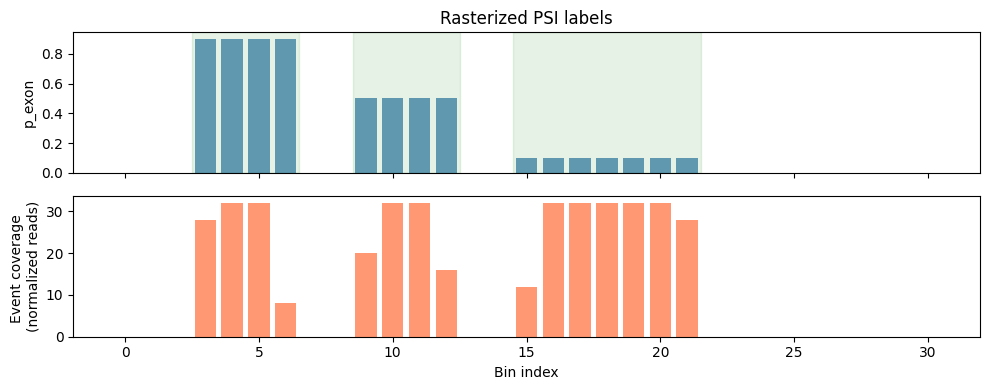

In [18]:
# Synthetic label intervals with PSI values
labels = pd.DataFrame({
    "Start": [100, 300, 500],
    "End":   [200, 400, 700],
    "p_exon": [0.9, 0.5, 0.1],  # high, medium, low inclusion
})

# Rasterize into 32bp bins across a 1000bp window
targets, events = rasterize_window(
    window_start=0, window_end=1000,
    bin_size=32, label_df=labels, n_bins=1000 // 32,
)

print(f"Window: 0-1000 bp, {len(targets)} bins at 32 bp resolution")
print(f"Bins with events: {(events > 0).sum()} / {len(targets)}")

# Visualize
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

ax1.bar(range(len(targets)), targets, color="steelblue", alpha=0.8)
ax1.set_ylabel("p_exon")
ax1.set_title("Rasterized PSI labels")

ax2.bar(range(len(events)), events, color="coral", alpha=0.8)
ax2.set_ylabel("Event coverage \n(normalized reads)")
ax2.set_xlabel("Bin index")

# Highlight source intervals
for _, row in labels.iterrows():
    b0 = int(row.Start) // 32
    b1 = int(row.End) // 32
    ax1.axvspan(b0 - 0.5, b1 + 0.5, alpha=0.1, color="green")

plt.tight_layout()
plt.show()

## 10. Edge Cases and Input Validation

Systematically testing boundary conditions to document expected behavior.

In [19]:
print("Edge case tests:\n")

# Empty sequence
enc_empty = one_hot_encode("")
print(f"1. Empty sequence:  shape={enc_empty.shape}  ✓")

# Single base
enc_one = one_hot_encode("A")
assert enc_one.shape == (1, 4)
print(f"2. Single base 'A': shape={enc_one.shape}, sum={enc_one.sum():.0f}  ✓")

# Chromosome too short for seq_len → no intervals generated
tiny_chrom = pd.DataFrame({"chrom": ["chrM"], "length": [1000]})
tiny_ivs = generate_intervals(tiny_chrom, seq_len=5000)
assert len(tiny_ivs) == 0
print(f"3. Chrom shorter than seq_len: {len(tiny_ivs)} intervals (correct)  ✓")

# Non-overlapping eval region raises ValueError
import pytest
try:
    genome_to_output_bins(
        input_start=0, input_end=524_288,
        eval_start=0, eval_end=100,
        bin_size=32, output_window=196_608,
    )
    print("4. Non-overlapping eval: should have raised ValueError  ✗")
except ValueError as e:
    print(f"4. Non-overlapping eval: ValueError raised as expected  ✓")

# All-zero mask produces zero loss
all_zero_mask = torch.zeros(1, 1, 10)
zero_loss = MaskedMSELoss()(torch.randn(1, 1, 10), torch.randn(1, 1, 10), all_zero_mask)
assert zero_loss.item() == 0.0
print(f"5. All-zero mask → loss = {zero_loss.item():.1f}  ✓")

# Empty label DataFrame for rasterize_window
empty_labels = pd.DataFrame({"Start": [], "End": [], "p_exon": []})
t, e = rasterize_window(0, 1000, 32, empty_labels, 1000 // 32)
assert t.sum() == 0 and e.sum() == 0
print(f"6. Empty labels → zero targets  ✓")

# Variant generation at specific positions only
single_var = generate_snvs("ACGT", positions=[0])
assert len(single_var) == 3
print(f"7. Single position variants: {len(single_var)} (3 alts)  ✓")

print("\nAll edge case tests passed!")

Edge case tests:

1. Empty sequence:  shape=(0, 4)  ✓
2. Single base 'A': shape=(1, 4), sum=1  ✓
3. Chrom shorter than seq_len: 0 intervals (correct)  ✓
4. Non-overlapping eval: ValueError raised as expected  ✓
5. All-zero mask → loss = 0.0  ✓
6. Empty labels → zero targets  ✓
7. Single position variants: 3 (3 alts)  ✓

All edge case tests passed!
